In [1]:
from NN_model_helper import (evaluate_fold_TL, set_freeze_mode, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from NN_model import ImprovedNN 

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet("../MW/artifacts/final_dataset_RDKit_60_MW_scaled.parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_unbrch_alkane,RDKit_fr_NH0,RDKit_NumAliphaticRings,...,RDKit_SMR_VSA10,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_SMR_VSA1,RDKit_PEOE_VSA9
0,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,140.0,Train,1,-0.463349,-0.150724,0.501978,-0.175089,0.199077,-0.497490,...,0.439775,0.104041,0.735690,1.519681,0.112624,-0.453481,-0.438297,-0.360924,0.237181,-0.207736
1,Brc1ccc2c(c1)c(=O)[nH]cc2,249.0,Train,0,1.259950,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,0.650404,0.104041,0.817902,-0.328623,-0.405680,0.348533,-0.691195,-0.360924,-1.118907,-0.952135
2,Nc1c(cnn1CCO)C(=O)N,239.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,1.072481,-0.497490,...,-0.381838,-0.662138,1.585215,-0.328623,-0.383935,-0.453481,-0.452140,-0.360924,-0.156318,1.227865
3,OC(C=O)CO,145.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,-0.756687,-1.428316,1.393386,-0.328623,-0.456272,-0.453481,-0.468240,0.182910,0.340142,-0.207736
4,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,273.0,Train,1,-0.463349,-6.046404,-0.661798,-0.175089,-0.674327,2.339192,...,2.875673,2.402576,-1.445669,3.367986,3.181505,5.962631,1.129382,2.902081,3.381234,2.025463


In [4]:
df_highMW = df[
    (df["Type"] == "Train") &
    (df["MW_label"] == 1)
].copy()

print("Shape:", df_highMW.shape)
print(df_highMW[["Type", "MW_label"]].value_counts())

Shape: (2719, 69)
Type   MW_label
Train  1           2719
Name: count, dtype: int64


In [5]:
df_highMW.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_unbrch_alkane,RDKit_fr_NH0,RDKit_NumAliphaticRings,...,RDKit_SMR_VSA10,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_SMR_VSA1,RDKit_PEOE_VSA9
0,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,140.00,Train,1,-0.463349,-0.150724,0.501978,-0.175089,0.199077,-0.497490,...,0.439775,0.104041,0.735690,1.519681,0.112624,-0.453481,-0.438297,-0.360924,0.237181,-0.207736
4,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,273.00,Train,1,-0.463349,-6.046404,-0.661798,-0.175089,-0.674327,2.339192,...,2.875673,2.402576,-1.445669,3.367986,3.181505,5.962631,1.129382,2.902081,3.381234,2.025463
6,CC(=O)OCC1=C(C(=O)O)N2C(SC1)C(C2=O)NC(=O)Cc1cccs1,160.25,Train,1,1.259950,-0.150724,-0.661798,-0.175089,0.199077,1.393631,...,2.039094,0.870219,1.068754,1.519681,-0.189036,0.348533,0.213206,0.726744,1.702587,-0.228699
21,O=C(c1ccccc1)NC1CCN(CC1)CCc1c[nH]c2c1cccc2,208.00,Train,1,2.983249,-0.150724,-0.661798,-0.175089,0.199077,0.448071,...,-0.031375,1.636397,0.094858,-0.328623,-0.456272,0.348533,0.233077,-0.360924,-0.652779,-0.952135
23,NC(=O)/C(=N\Nc1c(Cl)cccc1Cl)/c1nc2c(s1)cccc2,176.00,Train,1,1.259950,-0.150724,-0.661798,-0.175089,1.072481,-0.497490,...,3.087363,0.870219,0.225737,-0.328623,-0.404892,0.348533,-0.691195,-0.360924,-0.652779,1.971578


X_scaled shape: (2719, 65)
Num features: 65


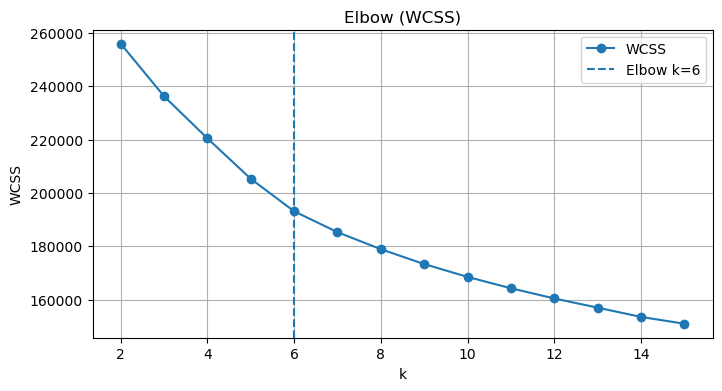

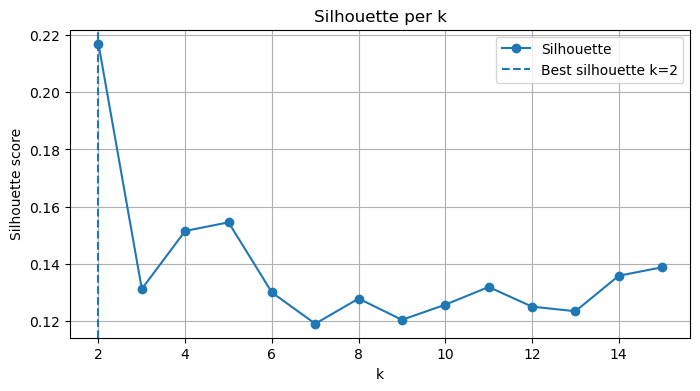

Elbow k: 6 | Best silhouette k: 2 | Selected k_opt: 6


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "MW_label"}
num_cols = df_highMW.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_highMW[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_highMW), "Cluster labels length != df rows (mismatch)."

df_clustered = df_highMW.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [7]:
df_clustered.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_unbrch_alkane,RDKit_fr_NH0,RDKit_NumAliphaticRings,...,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_SMR_VSA1,RDKit_PEOE_VSA9,Structure_Cluster
0,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,140.00,Train,1,-0.463349,-0.150724,0.501978,-0.175089,0.199077,-0.497490,...,0.104041,0.735690,1.519681,0.112624,-0.453481,-0.438297,-0.360924,0.237181,-0.207736,0
4,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,273.00,Train,1,-0.463349,-6.046404,-0.661798,-0.175089,-0.674327,2.339192,...,2.402576,-1.445669,3.367986,3.181505,5.962631,1.129382,2.902081,3.381234,2.025463,2
6,CC(=O)OCC1=C(C(=O)O)N2C(SC1)C(C2=O)NC(=O)Cc1cccs1,160.25,Train,1,1.259950,-0.150724,-0.661798,-0.175089,0.199077,1.393631,...,0.870219,1.068754,1.519681,-0.189036,0.348533,0.213206,0.726744,1.702587,-0.228699,1
21,O=C(c1ccccc1)NC1CCN(CC1)CCc1c[nH]c2c1cccc2,208.00,Train,1,2.983249,-0.150724,-0.661798,-0.175089,0.199077,0.448071,...,1.636397,0.094858,-0.328623,-0.456272,0.348533,0.233077,-0.360924,-0.652779,-0.952135,1
23,NC(=O)/C(=N\Nc1c(Cl)cccc1Cl)/c1nc2c(s1)cccc2,176.00,Train,1,1.259950,-0.150724,-0.661798,-0.175089,1.072481,-0.497490,...,0.870219,0.225737,-0.328623,-0.404892,0.348533,-0.691195,-0.360924,-0.652779,1.971578,1


In [8]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "MW_label", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 2719
Num features: 65
Num folds: 10

Fold  0 | Train: 2447 | Val:  272
Fold  1 | Train: 2447 | Val:  272
Fold  2 | Train: 2447 | Val:  272
Fold  3 | Train: 2447 | Val:  272
Fold  4 | Train: 2447 | Val:  272
Fold  5 | Train: 2447 | Val:  272
Fold  6 | Train: 2447 | Val:  272
Fold  7 | Train: 2447 | Val:  272
Fold  8 | Train: 2447 | Val:  272
Fold  9 | Train: 2448 | Val:  271


In [9]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

BASELINE_CKPT = Path("artifacts/general_best_lowMW_RDKit_60/general_best_fold_0.pt")

# --- scenarios: name, vector (for your notes), freeze_level used by evaluate_fold_TL ---

HIDDEN_LAYERS = [224, 112, 56]   # must match baseline arch
N_TRIALS      = 20

OUT_ROOT = Path("artifacts/TL_MW_RDKit_60")   # under the artifacts folder
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        # fixed freeze level; tune the rest
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=HIDDEN_LAYERS, dropout_rate=dropout_rate,
                learning_rate=learning_rate, weight_decay=weight_decay,
                batch_size=batch_size, freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6, patience=30, min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2":   float(r2),
                "q2":   float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "params": {
                "learning_rate": learning_rate,
                "weight_decay":  weight_decay,
                "batch_size":    batch_size,
                "dropout_rate":  dropout_rate,
                "hidden_layers": HIDDEN_LAYERS
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds":    fold_metrics
        }
        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # -- HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    # save study artifacts
    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)
    with open(SCEN_OUT / "best_params.json","w") as f:
        json.dump(study.best_params, f, indent=2)
    with open(SCEN_OUT / "best_value.txt","w") as f:
        f.write(f"{study.best_value:.6f}\n")
    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params:  {study.best_params}")

    # -- Final per-fold retrain with best params (to produce clean fold models + metrics)
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=HIDDEN_LAYERS,
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6, patience=30, min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)
        rows.append({"fold": fold_idx, "rmse": float(rmse), "r2": float(r2), "q2": float(q2), "checkpoint": str(ckpt)})

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "hidden_layers": HIDDEN_LAYERS,
        "best_params": best
    }
    with open(SCEN_OUT / "manifest.json","w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",        [0,0,0], 0),
    ("freeze_fc1",       [1,0,0], 1),
    ("freeze_fc1_fc2",   [1,1,0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}
print("\nSummary:", json.dumps(results, indent=2))

[I 2026-02-25 05:09:17,065] A new study created in memory with name: no-name-374bfda9-0a91-4e94-aa27-e7c66b19454d



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: TL on cpu | freeze=0 | lr=2.94976e-05
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

[Fold 0] Epoch    1 | Train 72.8896 | Val 74.9983 | ES 0/30
[Fold 0] Epoch   50 | Train 49.0542 | Val 51.9298 | ES 1/30
[Fold 0] Epoch  100 | Train 45.3713 | Val 47.5449 | ES 12/30
[Fold 0] Early stopping at epoch 136 (best Val Loss: 46.6330)
Fold 1: TL on cpu | freeze=0 | lr=2.94976e-05
Freeze Level 0: all layers trainable
[Fold 1] Epoch    1 | Train 73.1188 | Val 66.4369 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

...

[Fold 7] Epoch   50 | Train 49.8405 | Val 44.5921 | ES 2/30
[Fold 7] Epoch  100 | Train 47.6591 | Val 43.5184 | ES 0/30
[Fold 7] Epoch  150 | Train 48.5964 | Val 43.2072 | ES 0/30
[Fold 7] Early stopping at epoch 180 (best Val Loss: 43.2072)
Fold 8: TL on cpu | freeze=2 | lr=0.000201136
Freeze Level 2: freezing 2 block(s)
[Fold 8] Epoch    1 | Train 73.5550 | Val 65.9812 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

[Fold 8] Epoch   50 | Train 49.2166 | Val 44.9577 | ES 0/30
[Fold 8] Epoch  100 | Train 48.7234 | Val 44.2591 | ES 13/30
[Fold 8] Early stopping at epoch 133 (best Val Loss: 44.1095)
Fold 9: TL on cpu | freeze=2 | lr=0.000201136
Freeze Level 2: freezing 2 block(s)
[Fold 9] Epoch    1 | Train 72.4357 | Val 68.2498 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

[Fold 9] Epoch   50 | Train 49.0747 | Val 43.6295 | ES 2/30
[Fold 9] Epoch  100 | Train 48.9486 | Val 44.3599 | ES 22/30
[Fold 9] Early stopping at epoch 108 (best Val Loss: 43.1541)
[freeze_fc1_fc2] Best fold: 5 → artifacts/TL_MW_RDKit_60/freeze_fc1_fc2/final_fold_models/fold_5_best.pth

Summary: {
  "no_freeze": {
    "best": 40.53635673522949,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "best_fold": 5,
      "checkpoint": "artifacts/TL_MW_RDKit_60/no_freeze/final_fold_models/fold_5_best.pth",
      "hidden_layers": [
        224,
        112,
        56
      ],
      "best_params": {
        "learning_rate": 0.0004956214321744061,
        "weight_decay": 6.0126827037546755e-06,
        "batch_size": 32,
        "dropout_rate": 0.23406651920713778
      }
    }
  },
  "freeze_fc1": {
    "best": 40.6878116607666,
    "manifest": {
      "scenario": "freeze_fc1",
      "freeze_vector

In [10]:
from NN_model import ImprovedNN
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts/TL_MW_RDKit_60",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        # Build model
        input_size = state["network.0.weight"].shape[1]
        hidden_layers = manifest["hidden_layers"]
        dropout_rate = manifest["best_params"]["dropout_rate"]

        model = ImprovedNN(
            input_size=input_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
        )
        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts/TL_MW_RDKit_60",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/TL_MW_RDKit_60/no_freeze/final_fold_models/fold_5_best.pth
  └─ Best RMSE: 37.4799

Loaded model for scenario 'freeze_fc1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/TL_MW_RDKit_60/freeze_fc1/final_fold_models/fold_5_best.pth
  └─ Best RMSE: 38.2447

Loaded model for scenario 'freeze_fc1_fc2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/TL_MW_RDKit_60/freeze_fc1_fc2/final_fold_models/fold_5_best.pth
  └─ Best RMSE: 39.5574



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/3457756820.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

In [11]:
import pandas as pd
from pathlib import Path

def print_rmse_all_folds(
    root_dir="artifacts/TL_MW_RDKit_60",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)

    for tag in scenarios:
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        if not cv_metrics_path.exists():
            print(f"[WARN] Missing CV metrics for scenario '{tag}'")
            continue

        cv_df = pd.read_csv(cv_metrics_path)

        print(f"\nScenario: {tag}")
        print("-" * (10 + len(tag)))

        # Expecting columns like: fold, rmse, r2, q2, checkpoint, ...
        for _, row in cv_df.iterrows():
            fold = row.get("fold", "N/A")
            rmse = row["rmse"]
            print(f"  Fold {fold}: RMSE = {rmse:.4f}")

        print(f"  Mean RMSE: {cv_df['rmse'].mean():.4f}")
        print(f"  Std  RMSE: {cv_df['rmse'].std():.4f}")

# Run it
print_rmse_all_folds(
    root_dir="artifacts/TL_MW_RDKit_60",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)


Scenario: no_freeze
-------------------
  Fold 5: RMSE = 37.4799
  Fold 1: RMSE = 38.4914
  Fold 4: RMSE = 38.9856
  Fold 2: RMSE = 39.7580
  Fold 9: RMSE = 39.8574
  Fold 7: RMSE = 40.0293
  Fold 3: RMSE = 41.3949
  Fold 8: RMSE = 41.4992
  Fold 0: RMSE = 44.1905
  Fold 6: RMSE = 44.3758
  Mean RMSE: 40.6062
  Std  RMSE: 2.2843

Scenario: freeze_fc1
--------------------
  Fold 5: RMSE = 38.2447
  Fold 7: RMSE = 38.6027
  Fold 1: RMSE = 38.9595
  Fold 3: RMSE = 39.9354
  Fold 9: RMSE = 40.0341
  Fold 4: RMSE = 40.2455
  Fold 2: RMSE = 40.5704
  Fold 8: RMSE = 41.3764
  Fold 6: RMSE = 43.2387
  Fold 0: RMSE = 44.0104
  Mean RMSE: 40.5218
  Std  RMSE: 1.8930

Scenario: freeze_fc1_fc2
------------------------
  Fold 5: RMSE = 39.5574
  Fold 1: RMSE = 40.3486
  Fold 4: RMSE = 42.6227
  Fold 2: RMSE = 42.9405
  Fold 9: RMSE = 43.9142
  Fold 7: RMSE = 43.9699
  Fold 8: RMSE = 44.3259
  Fold 3: RMSE = 47.3841
  Fold 6: RMSE = 49.1818
  Fold 0: RMSE = 51.7523
  Mean RMSE: 44.5998
  Std  RMSE:

TEST EVALUATION

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

In [13]:
df = pd.read_parquet("../MW/artifacts/final_dataset_RDKit_60_MW_scaled.parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_unbrch_alkane,RDKit_fr_NH0,RDKit_NumAliphaticRings,...,RDKit_SMR_VSA10,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_SMR_VSA1,RDKit_PEOE_VSA9
0,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,140.0,Train,1,-0.463349,-0.150724,0.501978,-0.175089,0.199077,-0.497490,...,0.439775,0.104041,0.735690,1.519681,0.112624,-0.453481,-0.438297,-0.360924,0.237181,-0.207736
1,Brc1ccc2c(c1)c(=O)[nH]cc2,249.0,Train,0,1.259950,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,0.650404,0.104041,0.817902,-0.328623,-0.405680,0.348533,-0.691195,-0.360924,-1.118907,-0.952135
2,Nc1c(cnn1CCO)C(=O)N,239.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,1.072481,-0.497490,...,-0.381838,-0.662138,1.585215,-0.328623,-0.383935,-0.453481,-0.452140,-0.360924,-0.156318,1.227865
3,OC(C=O)CO,145.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,-0.756687,-1.428316,1.393386,-0.328623,-0.456272,-0.453481,-0.468240,0.182910,0.340142,-0.207736
4,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,273.0,Train,1,-0.463349,-6.046404,-0.661798,-0.175089,-0.674327,2.339192,...,2.875673,2.402576,-1.445669,3.367986,3.181505,5.962631,1.129382,2.902081,3.381234,2.025463


In [14]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (6888, 69)


In [20]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/no_freeze/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_no_freeze_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 41.6303
MAE : 32.1192
R^2 : 0.6553

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_no_freeze_RDKit_60.csv
Total RMSE (all): 41.630
RMSE (lowMW): 41.968
RMSE (highMW): 40.671


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/1708599611.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [ ]:
##################---------------------------- FC1 TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/freeze_fc1/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_freeze_fc1_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 41.6877
MAE : 32.1589
R^2 : 0.6544

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_freeze_fc1_RDKit_60.csv
Total RMSE (all): 41.688
RMSE (lowMW): 42.036
RMSE (highMW): 40.697


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/3941208020.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [22]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/freeze_fc1_fc2/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_freeze_fc1_fc2_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 44.4402
MAE : 34.4979
R^2 : 0.6072

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_freeze_fc1_fc2_RDKit_60.csv
Total RMSE (all): 44.440
RMSE (lowMW): 44.445
RMSE (highMW): 44.426


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/2078923357.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d